In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from typing import List, Tuple, Optional, Set, Dict
from collections import defaultdict

RANDOM_SEED = 41
np.random.seed(RANDOM_SEED)

from rdkit import Chem
from rdkit.Chem import AllChem, Descriptors, Draw
from rdkit.Chem.Scaffolds import MurckoScaffold
from rdkit.Chem.MolStandardize import rdMolStandardize
from rdkit import DataStructs
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')

2.4570930029063356
1.43432680120807
8.2521
-6.8762


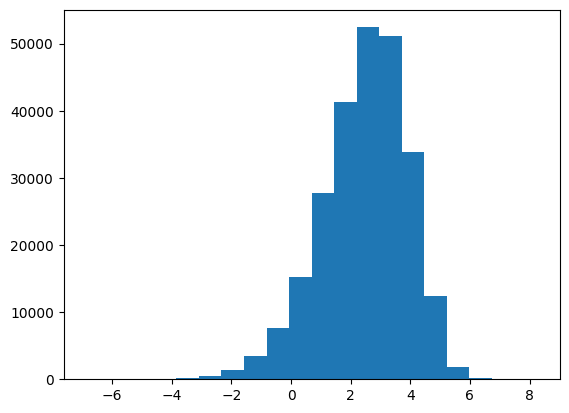

In [3]:
df = pd.read_csv("250k_rndm_zinc_drugs_clean_3.csv")

logPData = df["logP"].to_numpy()

print(logPData.mean())
print(logPData.std())
print(logPData.max())
print(logPData.min())

plt.hist(logPData, bins=20)
plt.show()

In [4]:
smiles_logP_dictionary = {}

for i, row in df.iterrows():
    mol = Chem.MolFromSmiles(df["smiles"][i])

    #rdMolStandardize.re

    lfg = rdMolStandardize.LargestFragmentChooser()
    mol = lfg.choose(mol)

    uncharger = rdMolStandardize.Uncharger()
    mol = uncharger.uncharge(mol)

    smiles = Chem.MolToSmiles(mol)

    smiles_value = smiles_logP_dictionary.get(smiles)
    if smiles_value == None:
        smiles_logP_dictionary[smiles] = (df["logP"][i], 1)
    else:
        smiles_logP_dictionary[smiles] = ((smiles_value[0]*smiles_value[1] + df["logP"][i])/(smiles_value[1]+1), smiles_value[1]+1)

print(f"{len(df["smiles"])} molecules reduced to {len(smiles_logP_dictionary)} smiles")

249455 molecules reduced to 249436 smiles


In [5]:
scaffold_dictionary = defaultdict(list)
valence_invalids = 0

for smiles, value in smiles_logP_dictionary.items():
    mol = Chem.MolFromSmiles(smiles)

    try: # From what I've understood, there are atoms with more than 4 bonds in the dataset, catch these errors and skip them.
        scaffold = MurckoScaffold.MakeScaffoldGeneric(mol)
    except Chem.AtomValenceException:
        valence_invalids += 1
        continue

    scaffold_smiles = Chem.MolToSmiles(scaffold, canonical=True)

    if scaffold_smiles != '' and scaffold.GetNumAtoms() > 0:
            scaffold_dictionary[scaffold_smiles].append(smiles)

print(f"{valence_invalids} molecules had invalid valences")
print(f"{len(smiles_logP_dictionary)} smiles reduced to {len(scaffold_dictionary)} scaffolds")

1 molecules had invalid valences
249436 smiles reduced to 219698 scaffolds


In [ ]:
training_fraction = 0.6
validation_fraction = 0.2
test_fraction = 1 - training_fraction - validation_fraction # 0.2

training_size = len(smiles_logP_dictionary) * training_fraction
validation_size = len(smiles_logP_dictionary) * validation_fraction
test_size = len(smiles_logP_dictionary) * test_fraction

training_set = []
validation_set = []
test_set = []

for references in scaffold_dictionary.values():
    if len(references) + len(test_set) <= test_size:
        for smiles in references:
            test_set.append((smiles, smiles_logP_dictionary[smiles][0]))
    elif len(references) + len(validation_set) <= validation_size:
        for smiles in references:
            validation_set.append((smiles, smiles_logP_dictionary[smiles][0]))
    elif len(references) + len(training_set) <= training_size:
        for smiles in references:
            training_set.append((smiles, smiles_logP_dictionary[smiles][0]))

print(len(test_set))
print(test_size)

49887
49887.200000000004
